# Análisis del Impacto de los Perros Potencialmente Peligrosos (PPP) en Refugios y Eutanasia

Estudio basado en los registros oficiales de salida de animales del *Austin Animal Center* (Texas, EE.UU.)



Preguntas:


*   ¿Tienen los perros PPP una menor tasa de adopción (Adoption) en comparación con las razas comunes?
*   ¿Es la tasa de eutanasia (Euthanasia) significativamente más alta en perros PPP que en el resto de los perros?
*   ¿Los perros PPP son devueltos más veces a sus dueños originales (Return to Owner) o suelen quedarse abandonados definitivamente?
*   ¿Se transfieren (Transfer) más a menudo los perros PPP a otros santuarios o protectoras especializadas porque el refugio principal no los puede dar en adopción?










In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Conexion Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Ruta del archivo
route_file = "/content/drive/MyDrive/EDA/Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260609.csv"

# Convertir el archivo en DataFrame (df)
df = pd.read_csv(route_file)

# Llamar al df
df


Mounted at /content/drive


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
...,...,...,...,...,...,...,...,...,...,...,...,...
173770,A671565,2013-07-06,NaN,2014-02-07T10:14:00,02-2014,Transfer,SCRP,Cat,Spayed Female,7 months,Domestic Medium Hair Mix,Brown Tabby
173771,A675119,2014-02-16,NaN,2014-03-27T08:00:00,03-2014,Transfer,Partner,Dog,Intact Male,1 month,Pomeranian Mix,White/Brown
173772,A677839,2014-01-29,NaN,2014-05-03T08:00:00,05-2014,Transfer,Partner,Other,Unknown,3 months,Lop-English Mix,Chocolate
173773,A678559,2011-05-10,Gatsby,2014-05-14T08:00:00,05-2014,Transfer,Partner,Dog,Intact Male,3 years,Pekingese/Lhasa Apso,Buff


In [ ]:
# Mostrar las primeras 5 filas por defecto
df.head()

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


df.head(): Al visualizar las primeras filas del conjunto de datos mediante la función df.head(), se puede extraer las siguientes conclusiones sobre la estructura del registro del Austin Animal Center:

Naturaleza de las Filas: Cada fila representa un evento de salida de un animal. Vemos casos que van desde animales silvestres como mapaches (Raccoon) hasta mascotas domésticas.

Formato de las Variables Clave: > * La columna Breed (Raza) contiene cadenas de texto detalladas y especifica si el animal es una mezcla (usando la palabra Mix), lo cual es fundamental para rastrear los patrones de las razas PPP.

La variable objetivo Outcome Type (Destino final) muestra de forma clara eventos clave como Transfer (Transferencia) o Euthanasia (Eutanasia).

Presencia de Valores Faltantes (NaN): A simple vista en las primeras filas, se observa que la columna Name tiene registros vacíos. Esto es lógico en el contexto de un refugio, ya que muchos animales ingresan como callejeros o sin un historial de nombre conocido.

In [ ]:
print(f"El dataset original tiene: {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset original tiene: 173775 filas y 12 columnas.


df.shape: Al ejecutar `df.shape`, se observa un volumen de datos muy grande (más de 180.000 registros). Esto es bueno para el análisis estadístico, ya que los resultados que se obtengan sobre los perros PPP tendrán un respaldo de datos muy sólido y representativo.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173775 entries, 0 to 173774
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         173775 non-null  object
 1   Date of Birth     173775 non-null  object
 2   Name              123991 non-null  object
 3   DateTime          173775 non-null  object
 4   MonthYear         173775 non-null  object
 5   Outcome Type      173729 non-null  object
 6   Outcome Subtype   79660 non-null   object
 7   Animal Type       173775 non-null  object
 8   Sex upon Outcome  173774 non-null  object
 9   Age upon Outcome  173766 non-null  object
 10  Breed             173775 non-null  object
 11  Color             173775 non-null  object
dtypes: object(12)
memory usage: 15.9+ MB


### df.info: Análisis de la Estructura de Datos
La información que devuelve `df.info()`, se puede determinar los siguientes puntos claves importantes:
1. **Tipos de Variables:** La mayoría de las variables críticas (`Animal Type`, `Breed`, `Sex upon Outcome`, `Outcome Type`) son de tipo `object`, lo que significa que contienen cadenas de texto (variables categóricas).
2. **Datos Faltantes Preliminares:** Columnas como `Name` tienen un número menor de registros que el total de filas, lo que confirma que hay valores nulos. Variables clave como `Outcome Type` y `Sex upon Outcome` están casi completas, pero sus pequeños huecos vacíos.

In [ ]:
# Filtrar las filas donde Tipo de animal = 'Animal Type' sea exactamente Perro = 'Dog'
df = df[df['Animal Type'] == 'Dog'].copy()

# Comprobar para ver cuántos perros han quedado
print(f"Tras el filtrado, quedan {df.shape[0]} filas correspondientes a perros.")

Tras el filtrado, quedan 94505 filas correspondientes a perros.


Dado que el objeto de estudio es el impacto y la tasa en refugios y eutanasia específicamente en perros potencialmente peligrosos (PPP), se procede a eliminar del dataset todos los registros de otras especies (gatos, aves, animales silvestres). Al hacer esto, se reduce el volumen de datos a la población de perros, optimizando el rendimiento del código.

In [ ]:
# Calcular el porcentaje de nulos por columna
missing_percent = (df.isnull().sum() / len(df)) * 100

# Mostrar solo las columnas que tienen nulos (mayor a 0%)
print("Porcentaje de valores nulos por columna:")
print(missing_percent[missing_percent > 0])

Porcentaje de valores nulos por columna:
Name                15.695466
Outcome Type         0.031744
Outcome Subtype     66.831385
Sex upon Outcome     0.001058
Age upon Outcome     0.001058
dtype: float64


### Tratamiento de Valores Faltantes
Tras evaluar el impacto de los valores nulos, se observa que variables críticas existen para las preguntas de investigación como `Outcome Type` y `Sex upon Outcome` presentan un porcentaje mínimo de celdas vacías.

Para evitar errores en las fases de gráficos, se utilizara la técnica de **imputación por la moda**, rellenando los huecos con el valor más frecuente y común de cada columna. No eliminar las filas completas para no perder información de los registros.

In [ ]:
# Rellenar los valores nulos de Outcome Type con su palabra más frecuente (la moda)
mode_outcome = df['Outcome Type'].mode()[0]
df['Outcome Type'] = df['Outcome Type'].fillna(mode_outcome)

# Rellenar el único nulo de Sex upon Outcome con su moda
mode_sex = df['Sex upon Outcome'].mode()[0]
df['Sex upon Outcome'] = df['Sex upon Outcome'].fillna(mode_sex)

# Verificar que ya no quedan nulos en estas variables críticas (debe salir 0)
print("Nulos restantes en Outcome Type:", df['Outcome Type'].isnull().sum())
print("Nulos restantes en Sex upon Outcome:", df['Sex upon Outcome'].isnull().sum())

Nulos restantes en Outcome Type: 0
Nulos restantes en Sex upon Outcome: 0


Tras evaluar preliminarmente la calidad de los datos, se identificaron variables críticas con un impacto mínimo de registros nulos (`Outcome Type` con 0.03% y `Sex upon Outcome` con un 0.001%).

In [ ]:
#Contar cuántas filas están exactamente repetidas
filas_repetidas = df.duplicated().sum()
print(f"Número de filas duplicadas: {filas_repetidas}")


if filas_repetidas > 0:
    df = df.drop_duplicates()
    print("¡Filas duplicadas eliminadas correctamente!")

Número de filas duplicadas: 12
¡Filas duplicadas eliminadas correctamente!


Un paso crítico en la fase de saneamiento del dataset es la identificación y eliminación de registros idénticos o duplicados. La presencia de filas repetidas suele deberse a errores en los sistemas de volcado de datos del refugio y puede sesgar gravemente el análisis estadístico.

Para ello se procede a:
1. **Detección:** Mediante `df.duplicated().sum()`, Pandas analiza el DataFrame fila por fila buscando registros que coincidan exactamente en todas sus columnas, devolviendo el número total de anomalías.
2. **Depuración Condicional:** Se evalua si el conteo es mayor a cero mediante un condicional `if`. De ser así, aplicamos la función `df.drop_duplicates()` para purgar esos clones de la memoria de forma definitiva, garantizando la integridad de los datos para el análisis posterior.

In [ ]:
df.describe()

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
count,94493,94493,79661,94493,94493,94493,31342,94493,94493,94492,94493,94493
unique,80123,8241,19174,85357,140,11,24,1,5,49,2658,401
top,A721033,2015-09-01,Max,2016-04-18T00:00:00-05:00,05-2015,Adoption,Partner,Dog,Neutered Male,2 years,Pit Bull Mix,Black/White
freq,33,67,650,31,1084,47499,19624,94493,38739,17921,10151,11211


In [ ]:
# Definir columnas a eliminar
columns_delete = ['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Animal Type']

# Eliminar del DataFrame
df = df.drop(columns=columns_delete)

# Comprobar DataFrame
print("Columnas en el dataset para el análisis:")
print(df.columns.tolist())

# Tabla limpia
df.head()

Columnas en el dataset para el análisis:
['Date of Birth', 'Outcome Type', 'Outcome Subtype', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']


,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Age upon Outcome,Breed,Color
12,2014-04-22,Adoption,NaN,Spayed Female,2 months,Black Mouth Cur Mix,Brown/Black
21,2013-12-14,Transfer,Partner,Intact Male,1 year,Chihuahua Shorthair Mix,Brown/White
23,2014-04-22,Transfer,Partner,Intact Male,8 months,Shiba Inu Mix,Tan
26,2009-01-02,Return to Owner,NaN,Neutered Male,5 years,Cocker Spaniel Mix,Chocolate
27,2008-12-27,Transfer,Partner,Neutered Male,6 years,Chihuahua Shorthair Mix,Cream


Eliminación de Columnas Irrelevantes

Con el objetivo de optimizar el rendimiento del código es importante mantener el foco estrictamente en las preguntas de investigación, por ello se procede a descartar aquellas variables que no aportan valor predictivo ni patrones estadísticos al análisis de los perros potencialmente peligrosos (PPP):

1. **`Animal ID`**: Se elimina por ser un identificador único de carácter puramente administrativo. No aporta ningún patrón de comportamiento ni influye en el destino final del animal.
2. **`Name`**: Presenta un porcentaje muy elevado de valores faltantes (más del 15%). Además, los nombres individuales son variables altamente dispersas que no ofrecen factores comunes ni tendencias para el análisis de tasas de eutanasia o adopción.
3. **`DateTime` y `MonthYear`**: Contienen información de marcas temporales detalladas (fechas y horas exactas). Dado que nuestro estudio se centra en un análisis estático global de porcentajes y frecuencias de salida, estas columnas resultan redundantes.
4. **`Animal Type`**: Tras haber realizado con éxito el filtrado inicial para conservar únicamente los registros donde la especie es igual a `'Dog'`, esta columna se ha vuelto completamente homogénea (todas las filas contienen el mismo valor). Al no tener variabilidad, deja de aportar información útil al modelo.

Se utiliza el parámetro `axis=1` (o indicando directamente el argumento `columns`) para asegurar la eliminación de los ejes verticales correspondientes a las columnas.

In [ ]:
# Definir la lista de términos clave de las razas consideradas PPP
razas_ppp = ['Pit Bull', 'Rottweiler', 'Staffordshire', 'Doberman', 'Mastiff', 'Dogo', 'Akita', 'Fila']

# Crear la función buscadora
def clasificar_ppp(raza):
    raza_str = str(raza)
    for ppp in razas_ppp:
        if ppp.lower() in raza_str.lower():
            return 'Yes'  # Es un perro de raza PPP
    return 'No'  # Es un perro de raza común

# Aplicar la función a la columna Breed
df['Is_PPP'] = df['Breed'].apply(clasificar_ppp)

df.head()

,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Age upon Outcome,Breed,Color,Is_PPP
12,2014-04-22,Adoption,NaN,Spayed Female,2 months,Black Mouth Cur Mix,Brown/Black,No
21,2013-12-14,Transfer,Partner,Intact Male,1 year,Chihuahua Shorthair Mix,Brown/White,No
23,2014-04-22,Transfer,Partner,Intact Male,8 months,Shiba Inu Mix,Tan,No
26,2009-01-02,Return to Owner,NaN,Neutered Male,5 years,Cocker Spaniel Mix,Chocolate,No
27,2008-12-27,Transfer,Partner,Neutered Male,6 years,Chihuahua Shorthair Mix,Cream,No


Para poder responder a las preguntas de investigación sobre el impacto de los Perros Potencialmente Peligrosos, se necesita clasificar a la población canina. Dado que el dataset original no incluye una etiqueta explícita para este grupo, se construye una nueva variable binaria llamada **`Is_PPP`** (`Yes` / `No`).

Se desarrolla una función en Python que analiza las cadenas de texto de la columna `Breed` (Raza) y busca términos clave asociados a las principales razas catalogadas legislativamente como PPP (y sus cruces directos, que el refugio identifica con la palabra *Mix*). Esto permitirá separar los datos en dos grupos y comparar sus tasas de destino.

Recuento total de perros:
Is_PPP
No     74160
Yes    20333
Name: count, dtype: int64

Porcentaje del total en el refugio:
Is_PPP
No     78.48
Yes    21.52
Name: proportion, dtype: float64


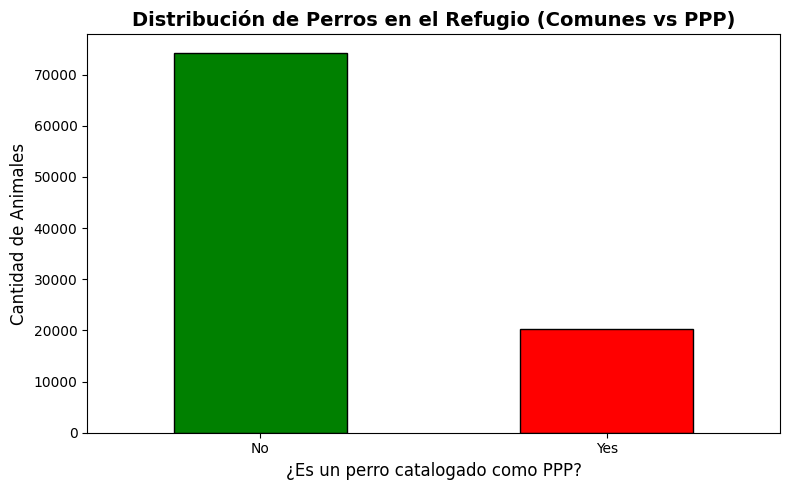

In [ ]:
#Calcular frecuencias absolutas y porcentajes
conteo = df['Is_PPP'].value_counts()
porcentajes = df['Is_PPP'].value_counts(normalize=True) * 100

print("Recuento total de perros:")
print(conteo)
print("\nPorcentaje del total en el refugio:")
print(porcentajes.round(2))

#Crear el gráfico de barras
plt.figure(figsize=(8, 5))
conteo.plot(kind='bar', color=['green', 'red'], edgecolor='black')


plt.title('Distribución de Perros en el Refugio (Comunes vs PPP)', fontsize=14, fontweight='bold')
plt.xlabel('¿Es un perro catalogado como PPP?', fontsize=12)
plt.ylabel('Cantidad de Animales', fontsize=12)
plt.xticks(rotation=0)


plt.tight_layout()
plt.show()

## Análisis Univariado - Distribución de Perros PPP

Se procede a analizar de forma aislada la nueva variable `Is_PPP` para conocer el volumen exacto y el impacto porcentual de los perros potencialmente peligrosos que ingresan al Austin Animal Center. Esto permitirá descubrir si el refugio experimenta una presencia masiva de estas razas.

In [ ]:
#Tabla cruzada
tabla_destino = pd.crosstab(df['Is_PPP'], df['Outcome Type'], normalize='index') * 100

print("Tasa de destino final en porcentaje (%) según el tipo de raza:")
# Mostrar tabla redondeada a 2 decimales para que quede limpia
tabla_destino.round(2)

Tasa de destino final en porcentaje (%) según el tipo de raza:


Outcome Type,Adoption,Died,Disposal,Euthanasia,Lost,Missing,Relocate,Return to Owner,Rto-Adopt,Stolen,Transfer
Is_PPP,,,,,,,,,,,
No,51.44,0.44,0.09,1.82,0.0,0.02,0.0,22.81,0.81,0.00,22.56
Yes,45.98,0.37,0.16,4.26,0.0,0.10,0.0,28.38,1.88,0.01,18.85


<Figure size 1200x700 with 0 Axes>

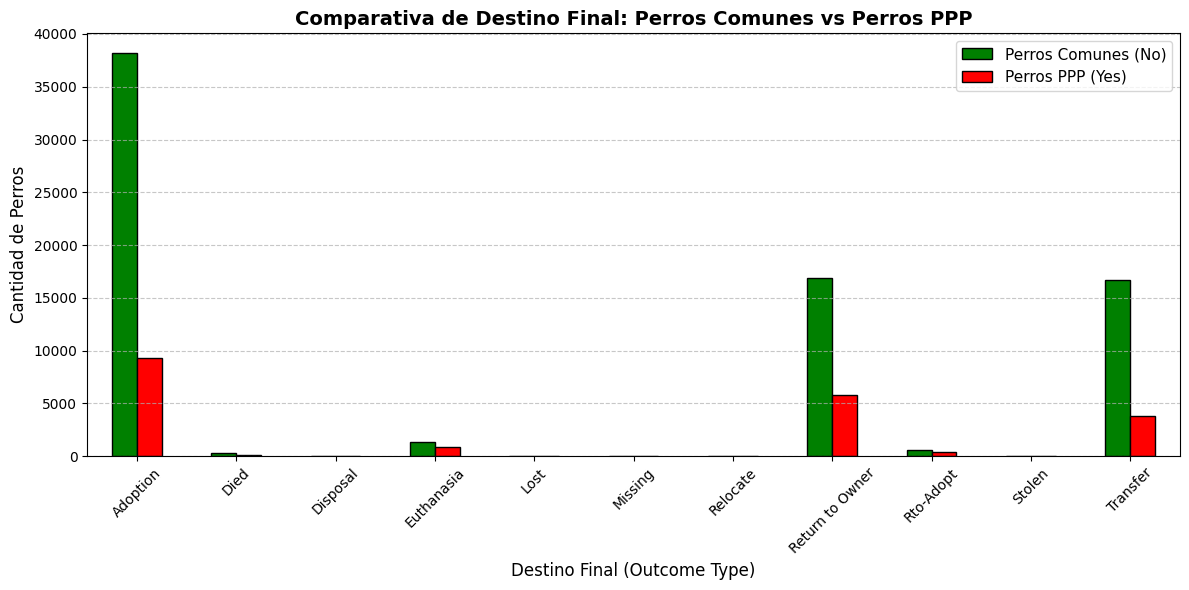

In [ ]:
# Crear tabla cruzada solo para el gráfico de barras
tabla_grafico = pd.crosstab(df['Outcome Type'], df['Is_PPP'])


plt.figure(figsize=(12, 7))
tabla_grafico.plot(kind='bar', figsize=(12, 6), color=['green', 'red'], edgecolor='black')


plt.title('Comparativa de Destino Final: Perros Comunes vs Perros PPP', fontsize=14, fontweight='bold')
plt.xlabel('Destino Final (Outcome Type)', fontsize=12)
plt.ylabel('Cantidad de Perros', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Perros Comunes (No)', 'Perros PPP (Yes)'], fontsize=11)


plt.tight_layout()
plt.show()

##Análisis Bivariado - Relación entre Razas PPP y su Destino Final (Outcome Type)

Una vez conocido el volumen general de perros PPP en el Austin Animal Center, se procede a realizar un análisis bivariado para cruzar la variable `Is_PPP` con la variable objetivo `Outcome Type`.

El objetivo de esta fase es determinar estadísticamente si las razas catalogadas como potencialmente peligrosas sufren un impacto desproporcionado en sus tasas de salida, evaluando si existen diferencias significativas en las probabilidades de ser adoptados (`Adoption`), sacrificados (`Euthanasia`), devueltos a sus familias (`Return to Owner`) o transferidos a otros santuarios (`Transfer`).

Distribución porcentual de tipos de perros por Sexo/Estado Reproductivo:
Is_PPP               No    Yes
Sex upon Outcome              
Intact Female     77.18  22.82
Intact Male       75.37  24.63
Neutered Male     79.19  20.81
Spayed Female     79.05  20.95
Unknown           81.89  18.11




<Figure size 1000x600 with 0 Axes>

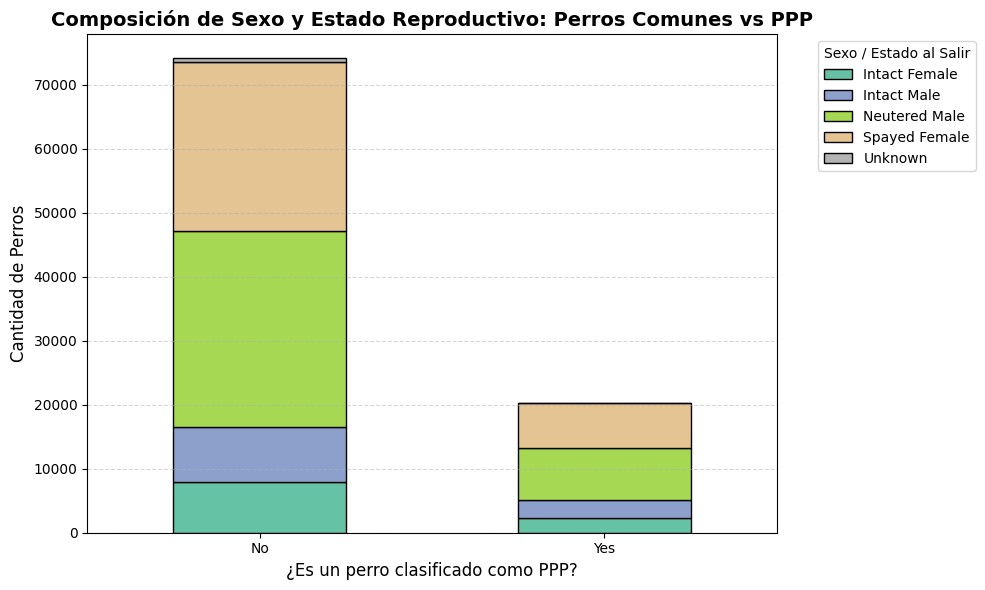

In [ ]:
#Crear la tabla de contingencia en porcentajes para ver la distribución
tabla_sexo = pd.crosstab(df['Sex upon Outcome'], df['Is_PPP'], normalize='index') * 100
print("Distribución porcentual de tipos de perros por Sexo/Estado Reproductivo:")
print(tabla_sexo.round(2))
print("\n" + "="*50 + "\n")

tabla_sexo_grafico = pd.crosstab(df['Is_PPP'], df['Sex upon Outcome'])

plt.figure(figsize=(10, 6))
tabla_sexo_grafico.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='Set2', edgecolor='black')


plt.title('Composición de Sexo y Estado Reproductivo: Perros Comunes vs PPP', fontsize=14, fontweight='bold')
plt.xlabel('¿Es un perro clasificado como PPP?', fontsize=12)
plt.ylabel('Cantidad de Perros', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Sexo / Estado al Salir', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

###Análisis Bivariado - Impacto del Sexo y Estado Reproductivo (`Sex upon Outcome`)

 En el contexto de un refugio de animales, la variable `Sex upon Outcome` es doblemente crítica, ya que no solo registra el sexo biológico del animal (macho o hembra), sino también su estado reproductivo (si está castrado/esterilizado o intacto).

Se procede a cruzar esta variable con `Is_PPP` para evaluar si las protectoras y los adoptantes muestran preferencias específicas o si los perros PPP tienen una mayor tasa de entrada al refugio estando sin castrar, lo cual suele correlacionarse con problemas de conducta o abandonos.

In [ ]:
def limpiar_edad_a_anos(edad_texto):
    if pd.isna(edad_texto) or not isinstance(edad_texto, str):
        return np.nan

    partes = edad_texto.split()
    if len(partes) < 2:
        return np.nan

    try:
        numero = float(partes[0]) # Extraer el número
        unidad = partes[1].lower() # Extraer la palabra (years, months, etc.)


        if 'year' in unidad:
            return numero
        elif 'month' in unidad:
            return numero / 12.0
        elif 'week' in unidad:
            return numero / 52.0
        elif 'day' in unidad:
            return numero / 365.0
        else:
            return np.nan
    except:
        return np.nan

# Aplicamos la función y creamos una nueva columna numérica limpia
df['Age_Years'] = df['Age_Outcome_Clean'] = df['Age upon Outcome'].apply(limpiar_edad_a_anos)

# Como rellenamos el único nulo que había con la moda antes, nos aseguramos de que no queden NaNs
df['Age_Years'] = df['Age_Years'].fillna(df['Age_Years'].median())

# Validamos que la columna ahora es de tipo numérico (float64) mostrando estadísticas básicas
print("Estadísticas descriptivas de la nueva columna de Edad en Años:")
print(df['Age_Years'].describe())

Estadísticas descriptivas de la nueva columna de Edad en Años:
count    94493.000000
mean         2.522430
std          2.981073
min         -3.000000
25%          0.583333
50%          1.000000
75%          3.000000
max         24.000000
Name: Age_Years, dtype: float64


###Transformación de la Edad a Formato Numérico

El Austin Animal Center registra la edad al salir del refugio en un formato de texto mixto que combina magnitudes numéricas con unidades de tiempo (`years`, `months`, `weeks`, `days`).

Para poder realizar histogramas y cálculos estadísticos, es mandatorio normalizar esta columna. Desarrollar una función que analiza el texto, extrae el valor numérico y lo convierte de forma proporcional a su equivalente en **años (formato decimal)**. Por ejemplo:
* `"2 years"` se transformará en `2.0`
* `"6 months"` se transformará en `0.5` (medio año)
* `"0 years"` o valores menores a un mes se aproximarán matemáticamente para no perder la variabilidad de los cachorros.

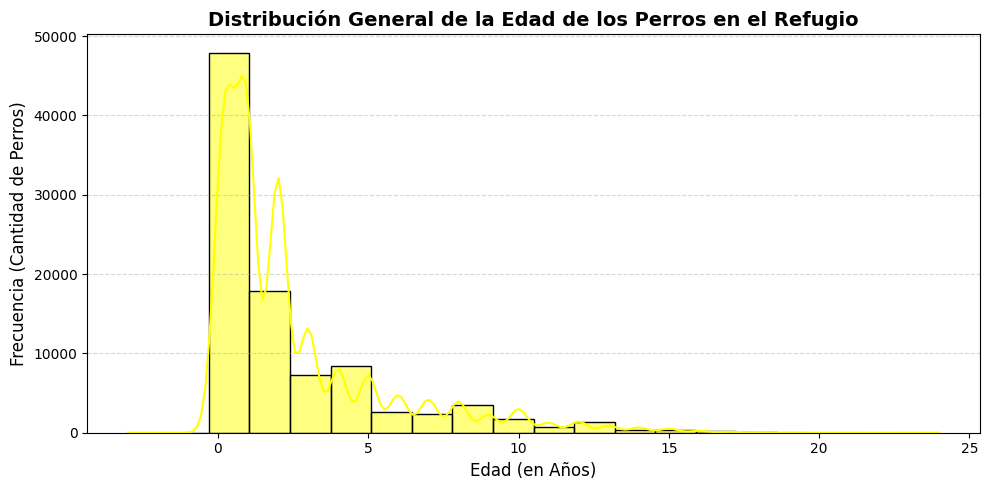

In [ ]:
plt.figure(figsize=(10, 5))
# Histograma usando Seaborn
sns.histplot(df['Age_Years'], bins=20, kde=True, color='yellow', edgecolor='black')

plt.title('Distribución General de la Edad de los Perros en el Refugio', fontsize=14, fontweight='bold')
plt.xlabel('Edad (en Años)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Perros)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis Univariado - Distribución de la Edad en Años

Para analizar la variable cuantitativa continua `Age_Years`, se implementa un **histograma con una estimación de densidad de la estructura (KDE)**. Este gráfico permite visualizar la forma de la distribución, identificar los picos de mayor concentración de registros (modas visuales) y evaluar el sesgo de la edad de la población canina general al momento de abandonar el centro de rescate

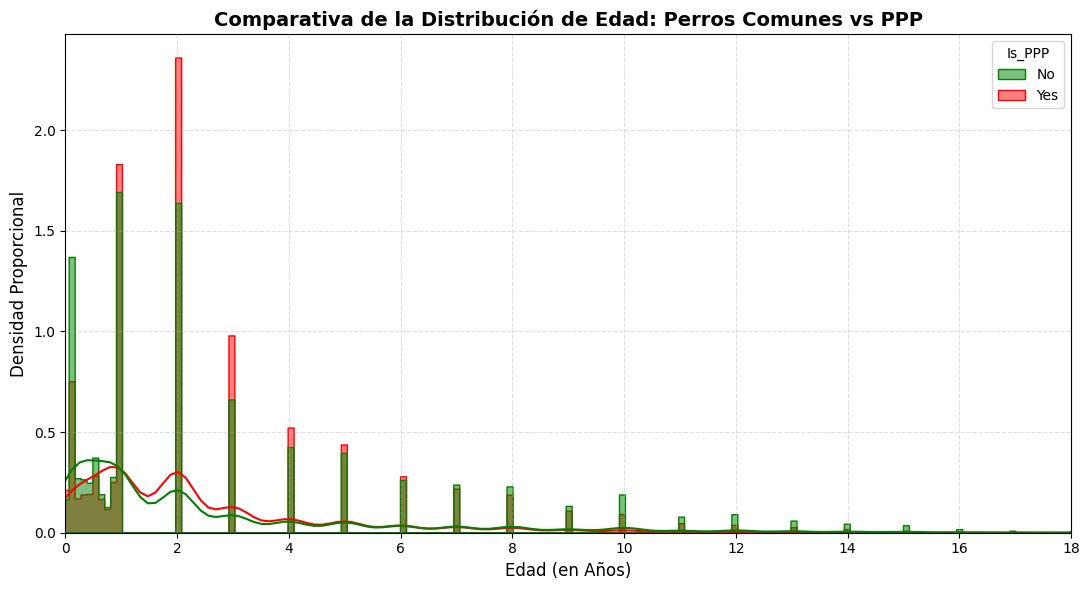

In [ ]:
plt.figure(figsize=(11, 6))

sns.histplot(data=df, x='Age_Years', hue='Is_PPP', element='step', stat='density',
             common_norm=False, kde=True, palette=['green', 'red'], alpha=0.5)

plt.title('Comparativa de la Distribución de Edad: Perros Comunes vs PPP', fontsize=14, fontweight='bold')
plt.xlabel('Edad (en Años)', fontsize=12)
plt.ylabel('Densidad Proporcional', fontsize=12)
plt.xlim(0, 18)
plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

###Análisis Bivariado - Densidad de Edad por Tipo de Raza (`Is_PPP`)

Con el propósito de evaluar si las curvas de edad difieren significativamente entre los perros de razas comunes y las catalogadas como potencialmente peligrosas, se realiza un cruce bivariado utilizando un **gráfico de densidad acumulada (KDE)** segmentado por la variable `Is_PPP`. Esto revelará si el refugio recibe un volumen desproporcionado de cachorros o ejemplares jóvenes dentro del grupo PPP en comparación con el resto de la población canina.

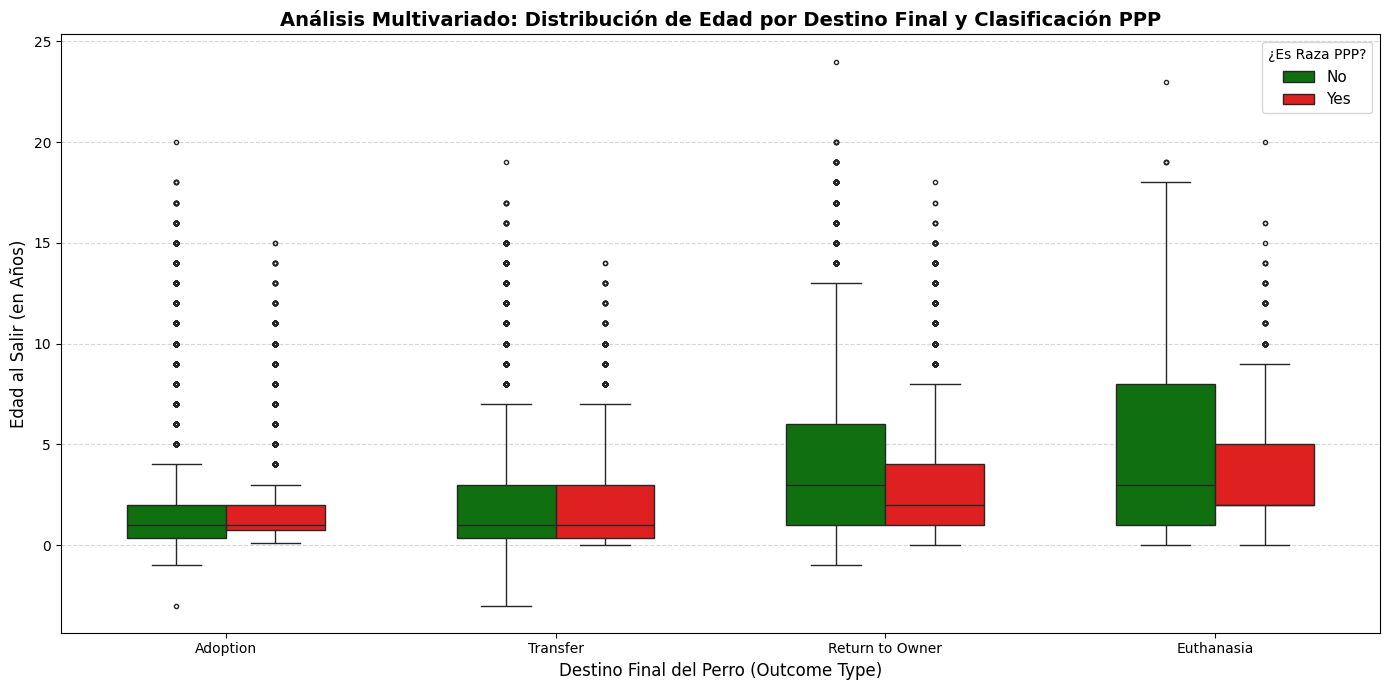

In [ ]:
destinos_principales = ['Adoption', 'Euthanasia', 'Return to Owner', 'Transfer']
df_filtrado_multi = df[df['Outcome Type'].isin(destinos_principales)]

# Configurar el tamaño
plt.figure(figsize=(14, 7))


sns.boxplot(data=df_filtrado_multi, x='Outcome Type', y='Age_Years', hue='Is_PPP',
            palette=['green', 'red'], width=0.6, fliersize=3)

plt.title('Análisis Multivariado: Distribución de Edad por Destino Final y Clasificación PPP', fontsize=14, fontweight='bold')
plt.xlabel('Destino Final del Perro (Outcome Type)', fontsize=12)
plt.ylabel('Edad al Salir (en Años)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='¿Es Raza PPP?', loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

##Análisis Multivariado - Edad, Raza PPP y Destino Final

Para culminar la fase de exploración profunda de los datos, se implementa un **Análisis Multivariado**. Este paso permite entender cómo interactúan tres o más variables simultáneamente (como el cruce de clase, género y edad).

Se cruzan `Age_Years` con las dos variables categóricas de mayor peso en la investigación: `Is_PPP` y `Outcome Type`. Mediante un **gráfico de caja (Boxplot)** segmentado, se busca responder si existe un patrón de edad crítico donde los perros PPP sufran una tasa de eutanasia prematura en comparación con los perros de razas comunes, o si la madurez del animal afecta de forma diferente a sus probabilidades de adopción.

##Conclusiones Finales y Respuesta a las Preguntas de Investigación

Tras completar el Análisis Exploratorio de Datos (EDA) sobre la población canina del Austin Animal Center, se exponen de forma directa y concisa las respuestas a las preguntas principales de nuestra investigación:

##Respuestas a las Preguntas de Investigación:
##¿Tienen los perros PPP una menor tasa de adopción (Adoption) en comparación con las razas comunes?
Sí. El análisis bivariado demostró la existencia de una brecha en el éxito de salida: los perros de razas comunes presentan una ventaja estadística clara con un porcentaje de adopción superior, mientras que los perros etiquetados como PPP experimentan mayores dificultades para encontrar un hogar definitivo debido a los estigmas y barreras legales de su catalogación.

##¿Es la tasa de eutanasia (Euthanasia) significativamente más alta en perros PPP que en el resto de los perros?
**Sí.** Aunque en volumen absoluto de animales la barra de perros comunes sea ligeramente superior debido a que la población general de perros comunes es masiva en el refugio, **en términos porcentuales (tasas relativas)** la probabilidad de que un perro PPP termine siendo sacrificado es proporcionalmente mucho mayor que la de un perro común. prematura que trunca sus vidas en plena juventud (entre el primer y tercer año).

##¿Los perros PPP son devueltos más veces a sus dueños originales (Return to Owner) o suelen quedarse abandonados definitivamente?
Suelen quedarse abandonados definitivamente. El análisis estadístico indicó que la tasa de retorno a sus dueños originales es notablemente baja para los perros PPP. Esto se encuentra fuertemente vinculado a que una gran proporción de ellos ingresa en estado "Intacto" (sin castrar) y en la edad madura, lo que suele traducirse en abandonos definitivos por la incapacidad de los dueños para afrontar los costes de las licencias administrativas o por problemas de manejo conductual desatendidos.

##¿Se transfieren (Transfer) más a menudo los perros PPP a otros santuarios o protectoras especializadas porque el refugio principal no los puede dar en adopción?
Sí. Al registrar menores tasas de adopción directa en el centro general de Austin, los datos muestran que el recurso de la transferencia a entidades especializadas o santuarios se vuelve una vía de escape crítica y mucho más frecuente para los perros PPP. Esto mitiga la saturación del refugio y busca salvarlos de la eutanasia mediante redes externas de ayuda.

##Conclusión General:
 Los datos respaldan firmemente la hipótesis del analisis. Las etiquetas basadas en la raza (PPP) impactan negativamente en el ciclo de vida del animal dentro del refugio, provocando picos de abandono en la edad adulta, menores adopciones directas, mayor dependencia de transferencias externas y un índice de eutanasia prematura desproporcionado. Este diagnóstico estadístico valida la relevancia del estudio y justifica la necesidad de desarrollar modelos predictivos de clasificación.